# Configuration

In [146]:
N_SAMPLES_GENERATED = 100000
N_SAMPLES_SAMPLED = 100000

NUMERIC_DEGREE_OF_PRECISION = 10000
CATEGORICAL_SKEW = 0.7

# Imports

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import ttest_ind

import torch
import torch.nn as nn
import torch.nn.functional as F

# Definitions

In [148]:
"""
A base class for sampling data from a simulated distribution. If instantiated, draws random datapoints from the data fit to

data: The data the simulated distribution will draw from
n_datapoints: The number of datapoints the simulated distribution can draw from

init: Initializes the simulated distribution to be fit
fit: Sets the data the simulated distribution should draw from
sample: Pulls a given number of random samples from the simulated distribution
"""
class Distribution():
    """
    Initializes the simulated distribution to be fit
    """
    def __init__(self):
      self.data = None
      self.n_datapoints = 0
    """
    Sets the data the simulated distribution should draw from

    data: The datapoints to sample from in the future
    """
    def fit(self, data):
      self.data = data
      self.n_datapoints = data.shape[0]
    """
   Pulls a given number of random samples from the simulated distribution

    n_samples: The number of samples to pull

    returns: Given number of datapoints from the simulated distribution
    """
    def sample(self, n_samples=1):
      return self.data[torch.randints(self.n_datapoints, (n_samples,))]

In [149]:
"""
A class for simulating a numeric distribution to any finite degree of precision by imagining the distribution as a set of uniform distributions determined with equal frequency buckets

precision_degree: The number of buckets the data is divided into, and the number of uniform distributions the simulated distribution is made up of
bucket_means: The mean value of each bucket
bucket_lefts: The minimum value of each bucket, and the left edge of each uniform distribution
bucket_rights: The minimum value of the next largest bucket of each bucket, except for the rightmost bucket, where it is the maximum value in that bucket. Also the maximum value in each uniform distribution

init: Initializes the simulated distribution to be ready for fitting
fit: Divides given data into buckets to be drawn from later
sample: Draws a given number of samples from the simulated distribution
set_precision_degree: Sets the precision degree to a new value. Also undoes any fitting already done.
cdf: The cumulative density function of the simulated distribution
icdf: The inverse cumulative density function of the simulated distribution
drift_mean: Drifts the mean of the simulated distribution
drift_variance: Drifts the variance of the simulated distribution
drift_skew: Drifts the skew of the simulated distribution
transform_distribution: Transforms the simulated distribution according to passed function that takes in all bucket lefts, means, and rights at once
transform_elements: Transforms the simulated distribution according to passed function that takes in each bucket left, bucket mean, and bucket right
"""
class NumericDistribution(Distribution):
    """
    Initializes the simulated distribution to be ready for fitting

    precision_degree: The number of buckets the distribution should be divided into
    """
    def __init__(self, precision_degree=None):
        self.precision_degree = precision_degree

        if (self.precision_degree != None):
          self.bucket_means = torch.zeros((self.precision_degree,))
          self.bucket_lefts = torch.zeros((self.precision_degree,))
          self.bucket_rights = torch.zeros((self.precision_degree,))

    """
    Fits the simulated distribution to the data provided

    data: The data to fit the simulated distribution to as a 1D pytorch tensor.
    """
    def fit(self, data):
        if (self.precision_degree == None):
          self.precision_degree = data.shape[0]

          self.bucket_means = torch.zeros((self.precision_degree,))
          self.bucket_lefts = torch.zeros((self.precision_degree,))
          self.bucket_rights = torch.zeros((self.precision_degree,))

        sorted_data, _ = torch.sort(data)

        n_samples = sorted_data.shape[0]
        step_size = n_samples / self.precision_degree

        for bucket_i in range(self.precision_degree):
            left_bucket_i, right_bucket_i = int(bucket_i * step_size), int((bucket_i + 1) * step_size)
            current_bucket = sorted_data[left_bucket_i:right_bucket_i]

            self.bucket_means[bucket_i] = torch.mean(current_bucket)
            self.bucket_lefts[bucket_i] = current_bucket[0]
            self.bucket_rights[bucket_i] = sorted_data[min(right_bucket_i, sorted_data.shape[0] - 1)]

    """
    Generates new samples from the simulated distribution

    n_samples: The number of samples to be generated

    returns: given number of samples from the distribution in a 1D pytorch tensor
    """
    def sample(self, n_samples=1):
        #random_nums = torch.rand((n_samples,))
        #return self.icdf(random_nums)

        bucket_indices = torch.randint(self.precision_degree, (n_samples,))
        sample_magnitudes = torch.rand((n_samples,))

        sample_mins, sample_maxes = self.bucket_lefts[bucket_indices], self.bucket_rights[bucket_indices]
        samples = sample_mins + sample_magnitudes * (sample_maxes - sample_mins)
        return samples

    """
    The cumulative density function of the simulated distribution

    values: The values to be passed into the cumulative density function as a 1D pytorch tensor

    returns: The portion of the simulated distribution less than or equal to each value as a 1D pytorch tensor
    """
    def cdf(self, values):
        value_bucket_indices = torch.tensor([torch.nonzero(values[i] > self.bucket_lefts)[-1] for i in range(values.shape[0])])

        value_bucket_lefts = self.bucket_lefts[value_bucket_indices]
        value_bucket_rights = self.bucket_rights[value_bucket_indices]

        cdf_values = (value_bucket_indices.float() + (values - value_bucket_lefts) / (value_bucket_rights - value_bucket_lefts)) / self.precision_degree

        return cdf_values
    """
    The inverse cumulative density function of the simulated distribution

    values: Values in range range [0-1] representing portions of the simulated distribution to be passed into the inverse cumulative density function as a 1D pytorch tensor

    returns: The values in the simulated distribution such that they have a portion of the simulated distribution less than or equal themselves equal to the passed values
    """
    def icdf(self, values):
        value_bucket_indices = torch.floor(values * self.precision_degree).long()
        value_bucket_magnitudes = (values % (1 / self.precision_degree)) * self.precision_degree

        icdf_mins, icdf_maxes = self.bucket_lefts[value_bucket_indices], self.bucket_rights[value_bucket_indices]
        icdf_values = icdf_mins + value_bucket_magnitudes * (icdf_maxes - icdf_mins)
        return icdf_values

    """
    Sets the degree of precision for the model to a new value. Also resets bucket means, lefts, and rights

    new_precision_degree: The new degree of precision to use
    """
    def set_precision_degree(self, new_precision_degree):
        self.precision_degree = new_precision_degree

        self.bucket_means = torch.zeros((self.precision_degree,))
        self.bucket_lefts = torch.zeros((self.precision_degree,))
        self.bucket_rights = torch.zeros((self.precision_degree,))

    """
    Drifts the mean of the simulated distribution, affecting the means, lefts, and rights of all buckets

    alpha: The amount to shift the mean by
    """
    def drift_mean(self, alpha):
        self.bucket_means = self.bucket_means + alpha
        self.bucket_lefts = self.bucket_lefts + alpha
        self.bucket_rights = self.bucket_rights + alpha
    """
    Drifts the variance of the simulated distribution, affecting the means, lefts, and rights of all buckets

    alpha: The percentage to shift the variance by
    """
    def drift_variance(self, alpha):
        overall_mean = torch.mean(self.bucket_means)
        self.bucket_means = (1 + alpha) * (self.bucket_means - overall_mean) + overall_mean
        self.bucket_lefts = (1 + alpha) * (self.bucket_lefts - overall_mean) + overall_mean
        self.bucket_rights = (1 + alpha) * (self.bucket_rights - overall_mean) + overall_mean
    """
    Drifts the skew of the simulated distribution, affecting the means, lefts, and rights of all buckets

    alpha: The value to shift the skew by
    """
    def drift_skew(self, alpha):
        self.bucket_means = torch.sign(self.bucket_means) * torch.pow(self.bucket_means, 1 + (alpha / 2))

    """
    Transforms the simulated distribution as a whole according to the given function

    f: The function to transform the distribution. Takes the bucket means, bucket lefts, and bucket rights of the simulated distribution as input, and should return the transformed bukcet means, bucket lefts, and bucket rights
    """
    def transform_distribution(self, f):
        self.bucket_means, self.bucket_lefts, self.bucket_rights = f(self.bucket_means, self.bucket_lefts, self.bucket_rights)
    """
    Transforms the simulated distribution by transforming each element according to the given function

    f: The function to transform the distribution. Takes in a bucket mean, bucket left, and bucket right as input, and should return a transformed bucket mean, bucket left, and bucket right
    """
    def transform_elements(self, f):
        for bucket_i in range(self.precision_degree):
            self.bucket_means[bucket_i], self.bucket_lefts[bucket_i], self.bucket_rights[bucket_i] = f(self.bucket_means[bucket_i], self.bucket_lefts[bucket_i], self.bucket_rights[bucket_i])

In [150]:
"""
A class for simulating a categorical distribution to be sampled from

n_categories: The number of categories in the distribution
category_portions: The portion of the simulated distribution that each category makes up stored as a 1D pytorch tensor
thresholds: Cumulative sums of category_portions. A cumulative version of the simulated distribution

init: Initializes the simulated distribution to be ready for fitting
fit: Fits the simulated distribution to provided data
sample: Pulls a given number of samples from the simulated distribution
"""
class CategoricalDistribution(Distribution):
    """
    Initializes the simulated distribution to be ready for fitting
    """
    def __init__(self):
        self.n_categories = 0
        self.category_portions = torch.zeros((0,))
        self.thresholds = torch.zeros((0,))

    """
    Fits the simulated distribution to provided data

    data: The data to fit the simulated distribution to represented as a 1D pytorch tensor of integers, where each unique integer represents a category starting at 0
    """
    def fit(self, data):
        self.n_categories = int(torch.max(data).item()) + 1
        n_samples = data.shape[0]

        self.category_portions = torch.zeros((self.n_categories,))
        for category_i in range(self.n_categories):
            self.category_portions[category_i] = torch.sum(data == category_i) / n_samples

        self.thresholds = torch.zeros((self.n_categories,))
        for category_i in range(self.n_categories):
            self.thresholds[category_i:] += self.category_portions[category_i]

    """
    Pulls a given number of samples from the simulated distribution

    n_samples: The number of samples to pull from the simulated distribution

    returns: The given number of samples as a 1D pytorch tensor filled with random integers in proportion to the categories in the simulated distribution
    """
    def sample(self, n_samples=1):
        random_nums = torch.rand((n_samples,))
        samples = torch.zeros((n_samples,))

        adjusted_thresholds = torch.cat((torch.tensor([0]), self.thresholds))

        for category_i in range(self.n_categories):
            current_min_threshold = adjusted_thresholds[category_i]
            current_max_threshold = adjusted_thresholds[category_i + 1]

            samples = torch.where(torch.logical_and(random_nums >= current_min_threshold, random_nums < current_max_threshold), torch.full((n_samples,), category_i), samples)

        return samples

In [151]:
"""
A class for putting several independent distributions together

distributions: The distributions that make up the compound distribution
n_distributions: The number of distributions that make up the compound distribution

init: Initializes the compound distribution to be ready for fitting
fit_specific: Fit a specific distribution that makes up the compound distribution to given data
fit: Fit all distributions that make up the compound distribution to given data
sample: Pull a given number of samples from the compound distribution
"""
class CompoundDistribution(Distribution):
  """
  Prepares the simulated distribution to be fit to data

  distributions: The independent distributions that make up the compound distributions
  """
  def __init__(self, distributions):
    self.distributions = distributions
    self.n_distributions = len(distributions)

  """
  Fits one distribution that makes up the compound distribution to the passed data

  data: The data to fit the simulated distribution to
  i: The index of the distribution to fit within the compound distribution's distributions
  """
  def fit_specific(self, data, i):
    self.distributions[i].fit(data)
  """
  Fits all distributions that make up the compiund distribution to the provided data

  data: The data to fit the distributions to. Should be a list, where the first distribution will be fit to the first entry, the second to the second, and so on
  """
  def fit(self, data):
    for i in range(self.n_distributions):
      self.fit_specific(data[i], i)

  """
  Samples from the simulated distribution

  n_samples: The number of samples to pull from the simulated distribution

  returns: A 2D pytorch tensor where each row is one sample from the compound distribution and each column is the sampling from one of the distributions making up the compound distribution
  """
  def sample(self, n_samples=1):
    samples = torch.stack([self.distributions[i].sample(n_samples=n_samples) for i in range(self.n_distributions)], dim=1)
    return samples

In [ ]:
"""
The cdf function for the standard normal distribution (mean=0, std=1)

values: Values from the standard normal distribution as a 1D pytorch tensor

returns: The portion of the standard normal distribution before and including each value as a 1D pytorch tensor
"""
def normal_cdf(values):
  return 0.5 * (1 + torch.erf(values / math.sqrt(2)))
"""
The inverse cdf function for the standard normal distribution (mean=0, std=1)

values: Values in the range [0, 1] as a 1D pytorch tensor

returns: The values in the standard normal distribution such that they have a portion of the standard normal distribution less than or equal themselves equal to the passed values
"""
def normal_inverse_cdf(values):
  return torch.erfinv(2 * values - 1) * math.sqrt(2)
"""
A class for creating a gaussian copula to sample from, attempting to maintain relationships in mutlivariate data

correlation_matrix: The correlation matrix for the features the copula is fit to
decomposition_matrix: The cholesky decomposition of the correlation matrix
cdfs: The cumulative density functions of the simulated distributions for each feature the copula is fit to
n_features: The number of features in the copula

init: Initializes the copula to be ready for fitting
fit: Fits the copula to the data given
sample: Generates samples form the simulated distribution of data
"""
class GaussianCopula(Distribution):
  """
  Initializes the copula to be ready for fitting
  """
  def __init__(self, precision_degree=None):
    self.correlation_matrix = torch.zeros((0, 0))
    self.decomposition_matrix = torch.zeros((0, 0))
    self.cdfs = []
    self.n_features = 0
    self.precision_degree = precision_degree
  """
  Fits the copula to the given data

  data: The data to fit the copula to as a 2D pytorch tensor where the rows are individual samples and the columns are all samples of a given feature
  """
  def fit(self, data):
    n_samples, n_features = data.shape

    sorted_indices = torch.argsort(data, dim=0)

    feature_ranks = torch.zeros(data.shape)
    for i in range(n_features):
      feature_ranks[:, i][sorted_indices[:, i]] = torch.arange(n_samples).float()

    normalized_feature_ranks = feature_ranks / n_samples
    correlation_matrix = torch.corrcoef(normalized_feature_ranks.T)
    cholesky_decomposition = torch.linalg.cholesky(correlation_matrix)

    self.correlation_matrix = correlation_matrix
    self.decomposition_matrix = cholesky_decomposition

    self.cdfs = []
    for i in range(n_features):
      new_cdf = NumericDistribution(precision_degree=self.precision_degree)
      new_cdf.fit(data[:, i])
      self.cdfs.append(new_cdf)

    self.n_features = n_features
  """
  Generates new samples from the simulated distribution using the copula

  n_samples: The number of samples desired to be generated

  returns: Generated samples from the simulated distribution as a 2D pytorch tensor where each row is a sample and each column is all samples of a feature
  """
  def sample(self, n_samples=1):
    #random_nums = torch.rand((n_samples, self.n_features))
    #icdf_values = normal_inverse_cdf(random_nums)
    icdf_values = torch.randn((n_samples, self.n_features))
    correlated_icdf_values = torch.stack([self.decomposition_matrix @ icdf_values[i, :] for i in range(n_samples)])
    correlated_random_nums = normal_cdf(correlated_icdf_values)
    samples = torch.stack([self.cdfs[i].icdf(correlated_random_nums[:, i]) for i in range(self.n_features)], dim=1)
    return samples

# Demonstration of Numeric Distribution

In [153]:
generated_data = torch.concat((torch.randn(N_SAMPLES_GENERATED // 4) - 2, 2 * torch.randn(N_SAMPLES_GENERATED // 2), 0.5 * torch.randn(N_SAMPLES_GENERATED // 4) + 3))

distribution = NumericDistribution(NUMERIC_DEGREE_OF_PRECISION)
distribution.fit(generated_data)

sampled_data = distribution.sample(N_SAMPLES_SAMPLED)

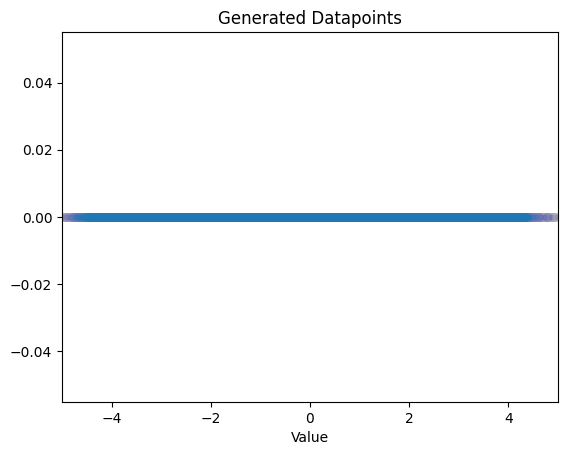

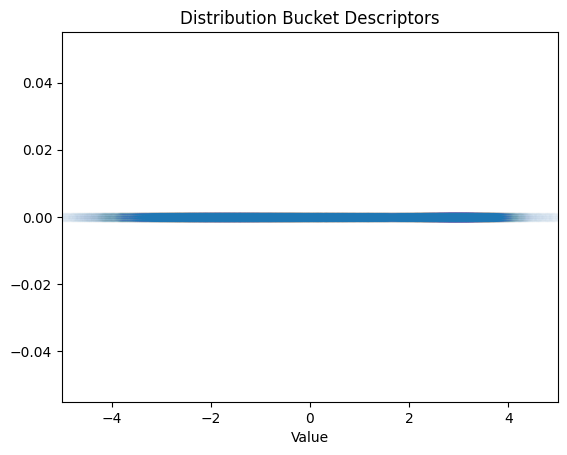

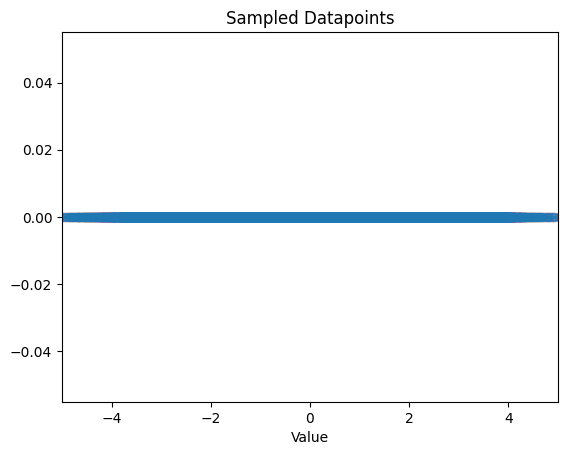

In [154]:
plt.scatter(generated_data, torch.zeros(N_SAMPLES_GENERATED), alpha=0.002)
plt.xlim(-5, 5)
plt.xlabel("Value")
plt.ylabel("")
plt.title("Generated Datapoints")
plt.show()

plt.scatter(distribution.bucket_means, torch.zeros(NUMERIC_DEGREE_OF_PRECISION), alpha=0.01)
plt.xlim(-5, 5)
plt.xlabel("Value")
plt.ylabel("")
plt.title("Distribution Bucket Descriptors")
plt.show()

plt.scatter(sampled_data, torch.zeros(N_SAMPLES_GENERATED), alpha=0.01)
plt.xlim(-5, 5)
plt.xlabel("Value")
plt.ylabel("")
plt.title("Sampled Datapoints")
plt.show()

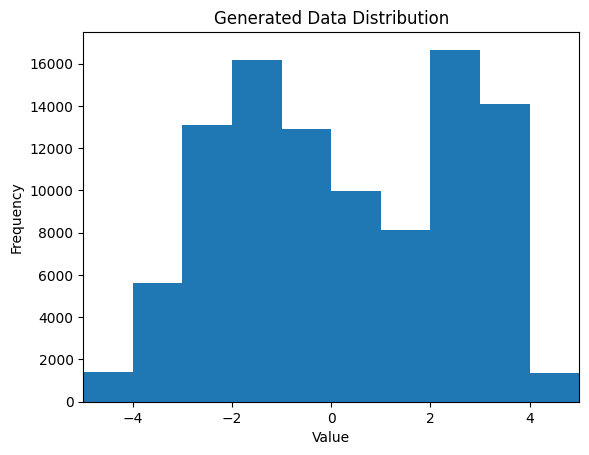

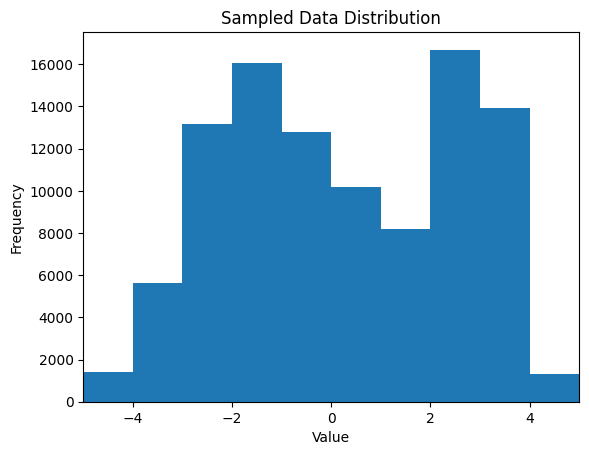

T-Test for generated and sampled distributions:
TtestResult(statistic=-0.17047366166511085, pvalue=0.8646378185562027, df=199997.94597723096)


In [155]:
plt.hist(generated_data, range=(-5, 5))
plt.xlim(-5, 5)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Generated Data Distribution")
plt.show()

plt.hist(sampled_data, range=(-5, 5))
plt.xlim(-5, 5)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Sampled Data Distribution")
plt.show()

print("T-Test for generated and sampled distributions:")
print(ttest_ind(torch.randn(N_SAMPLES_GENERATED), torch.randn(N_SAMPLES_GENERATED), equal_var=False))

In [156]:
pre_drift_generated = torch.randn((N_SAMPLES_GENERATED,))

distribution = NumericDistribution(NUMERIC_DEGREE_OF_PRECISION)
distribution.fit(pre_drift_generated)

pre_drift_sampled = distribution.sample(n_samples=N_SAMPLES_SAMPLED)

distribution.drift_mean(5)
mean_drifted_sampled = distribution.sample(n_samples=N_SAMPLES_SAMPLED)

distribution.drift_variance(3)
mean_and_variance_drifted_sampled = distribution.sample(n_samples=N_SAMPLES_SAMPLED)

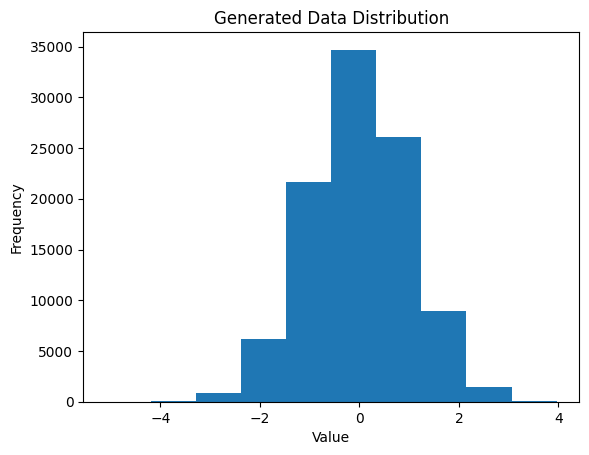

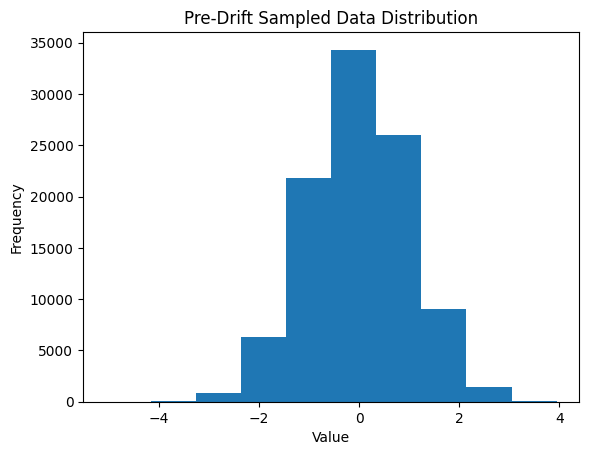

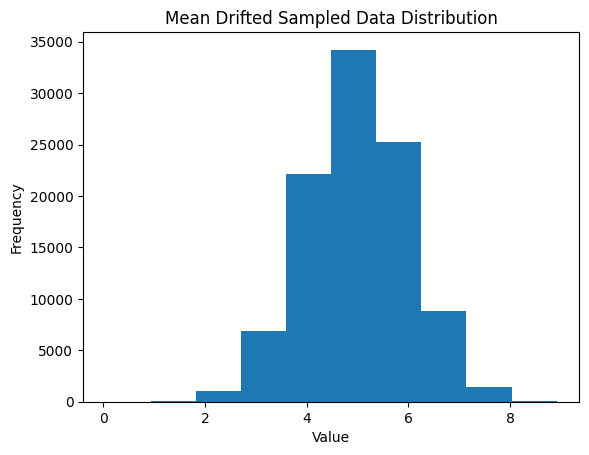

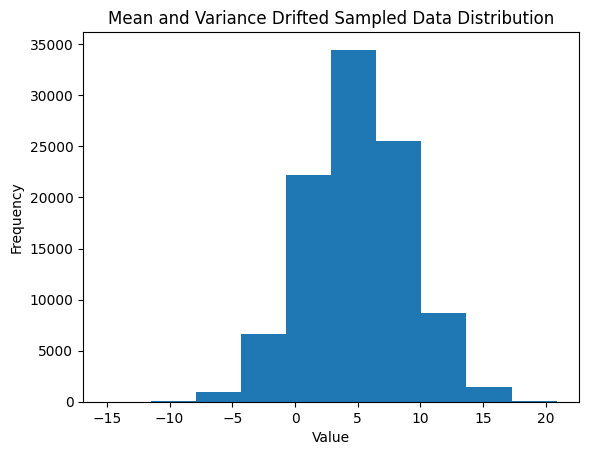

In [157]:
plt.hist(pre_drift_generated)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Generated Data Distribution")
plt.show()

plt.hist(pre_drift_sampled)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Pre-Drift Sampled Data Distribution")
plt.show()

plt.hist(mean_drifted_sampled)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Mean Drifted Sampled Data Distribution")
plt.show()

plt.hist(mean_and_variance_drifted_sampled)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Mean and Variance Drifted Sampled Data Distribution")
plt.show()

# Demonstration of Categorical Distribution

In [158]:
generated_data = torch.where(torch.rand(N_SAMPLES_GENERATED) < CATEGORICAL_SKEW, torch.zeros(N_SAMPLES_GENERATED), torch.ones(N_SAMPLES_GENERATED))

distribution = CategoricalDistribution()
distribution.fit(generated_data)

sampled_data = distribution.sample(N_SAMPLES_SAMPLED)

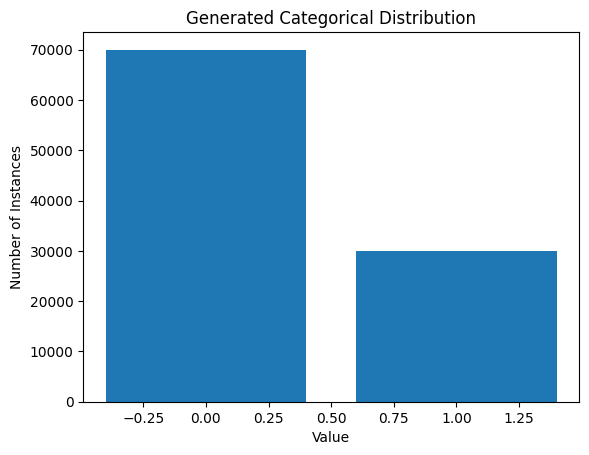

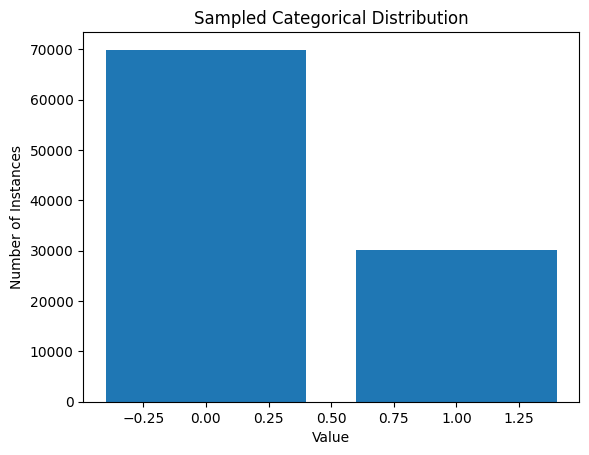

In [159]:
plt.bar([0, 1], [torch.sum(generated_data == 0), torch.sum(generated_data == 1)])
plt.xlabel("Value")
plt.ylabel("Number of Instances")
plt.title("Generated Categorical Distribution")
plt.show()

plt.bar([0, 1], [torch.sum(sampled_data == 0), torch.sum(sampled_data == 1)])
plt.xlabel("Value")
plt.ylabel("Number of Instances")
plt.title("Sampled Categorical Distribution")
plt.show()

# Demonstration of Compound Distribution

In [160]:
first_feature = torch.randn(N_SAMPLES_GENERATED)
second_feature = 2 * torch.randn(N_SAMPLES_GENERATED)
third_feature = torch.randint(3, (N_SAMPLES_GENERATED,))
generated_data = torch.stack((first_feature, second_feature, third_feature), dim=1)

distribution = CompoundDistribution([NumericDistribution(NUMERIC_DEGREE_OF_PRECISION), NumericDistribution(NUMERIC_DEGREE_OF_PRECISION), CategoricalDistribution()])
distribution.fit(generated_data.T)

sampled_data = distribution.sample(n_samples=N_SAMPLES_SAMPLED)

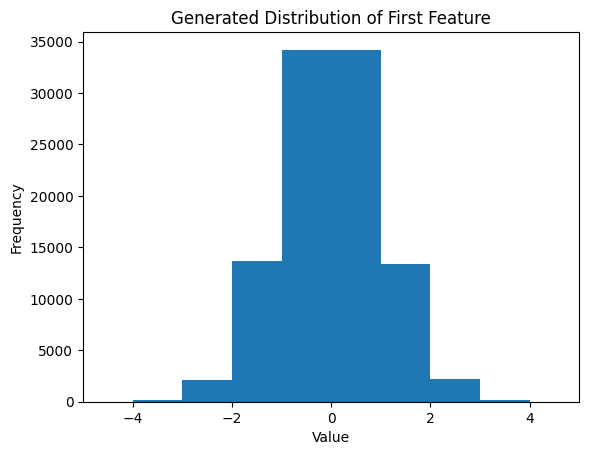

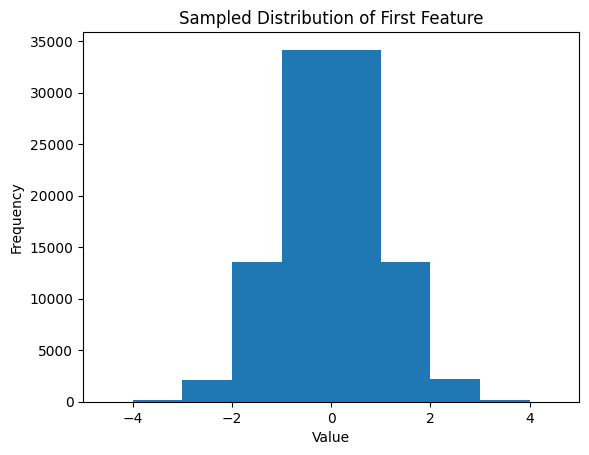

In [161]:
plt.hist(generated_data[:, 0], range=(-5, 5))
plt.xlim(-5, 5)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Generated Distribution of First Feature")
plt.show()

plt.hist(sampled_data[:, 0], range=(-5, 5))
plt.xlim(-5, 5)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Sampled Distribution of First Feature")
plt.show()

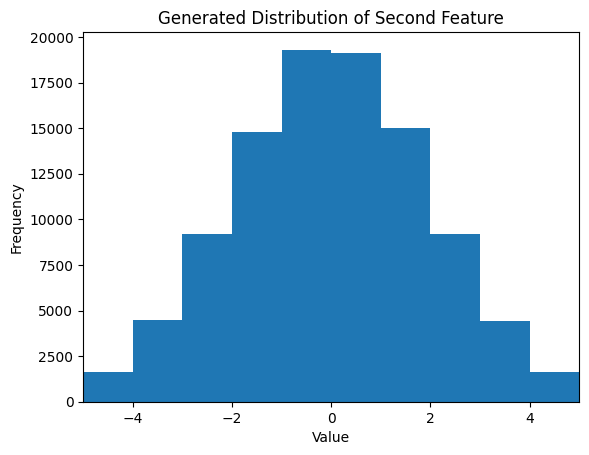

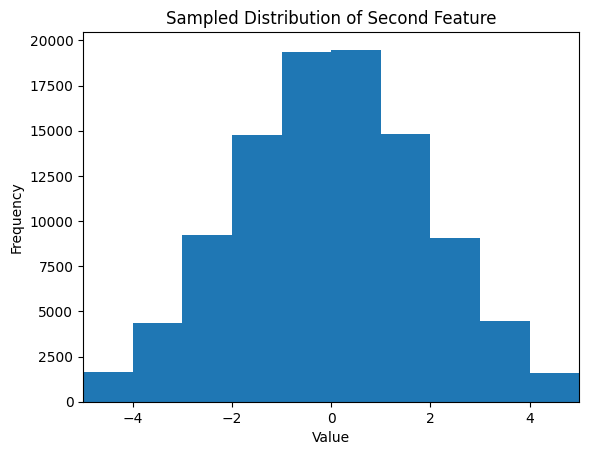

In [162]:
plt.hist(generated_data[:, 1], range=(-5, 5))
plt.xlim(-5, 5)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Generated Distribution of Second Feature")
plt.show()

plt.hist(sampled_data[:, 1], range=(-5, 5))
plt.xlim(-5, 5)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Sampled Distribution of Second Feature")
plt.show()

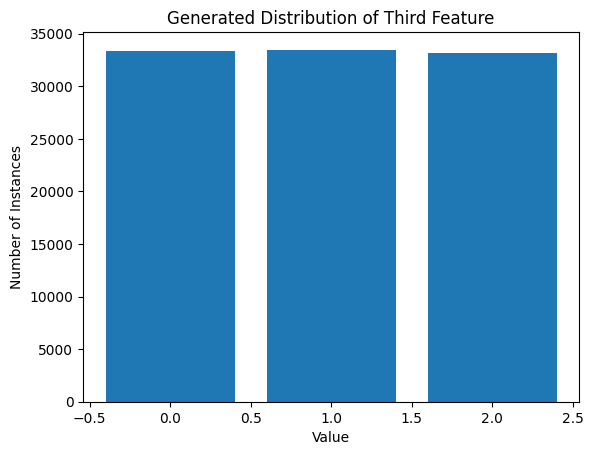

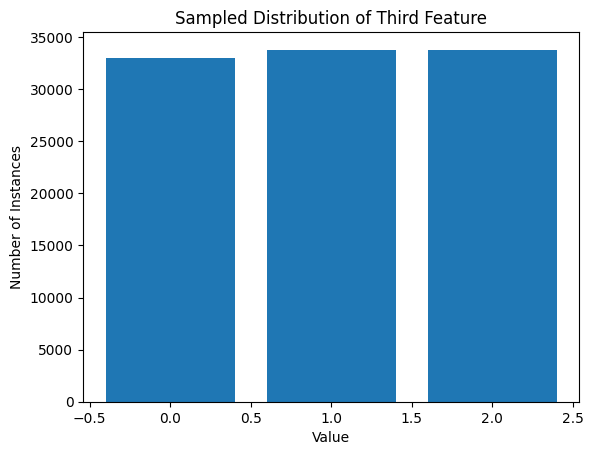

In [163]:
plt.bar([0, 1, 2], [torch.sum(generated_data[:, 2] == 0), torch.sum(generated_data[:, 2] == 1), torch.sum(generated_data[:, 2] == 2)])
plt.xlabel("Value")
plt.ylabel("Number of Instances")
plt.title("Generated Distribution of Third Feature")
plt.show()

plt.bar([0, 1, 2], [torch.sum(sampled_data[:, 2] == 0), torch.sum(sampled_data[:, 2] == 1), torch.sum(sampled_data[:, 2] == 1)])
plt.xlabel("Value")
plt.ylabel("Number of Instances")
plt.title("Sampled Distribution of Third Feature")
plt.show()

# Demonstration of Copula

In [164]:
feature_means = torch.tensor([-1.0, 1.0])
covariance_matrix = torch.stack([
    torch.tensor([1.0, 0.9]),
    torch.tensor([0.9, 1.0])
])

generator = torch.distributions.multivariate_normal.MultivariateNormal(feature_means, covariance_matrix=covariance_matrix)
generated_data = generator.sample((N_SAMPLES_GENERATED,))

distribution = GaussianCopula(precision_degree=NUMERIC_DEGREE_OF_PRECISION)
distribution.fit(generated_data)

sampled_data = distribution.sample(N_SAMPLES_SAMPLED)

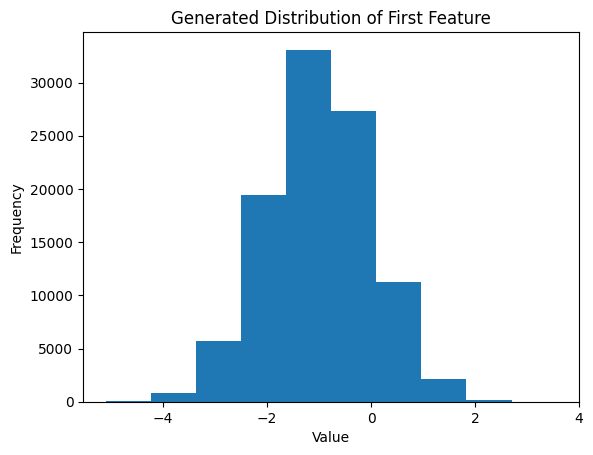

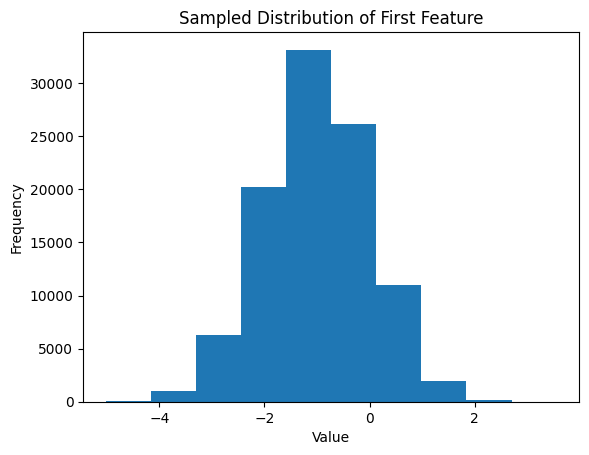

T-test results for the first feature of generated and sampled data:
TtestResult(statistic=0.2207590940305753, pvalue=0.8252802413334461, df=199997.98922847546)


In [166]:
plt.hist(generated_data[:, 0])
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Generated Distribution of First Feature")
plt.show()

plt.hist(sampled_data[:, 0])
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Sampled Distribution of First Feature")
plt.show()

print("T-test results for the first feature of generated and sampled data:")
print(ttest_ind(generated_data[:, 0], sampled_data[:, 0], equal_var=False))

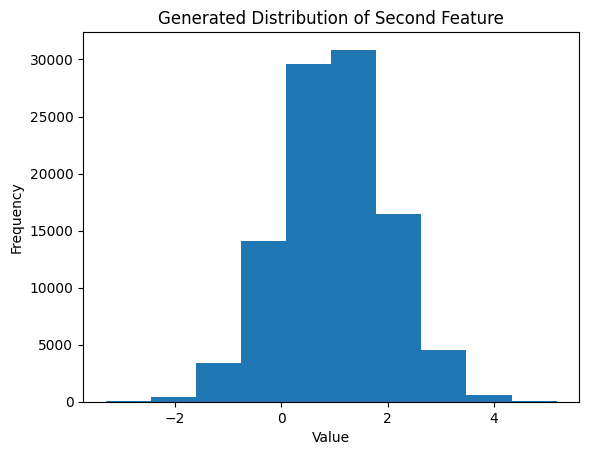

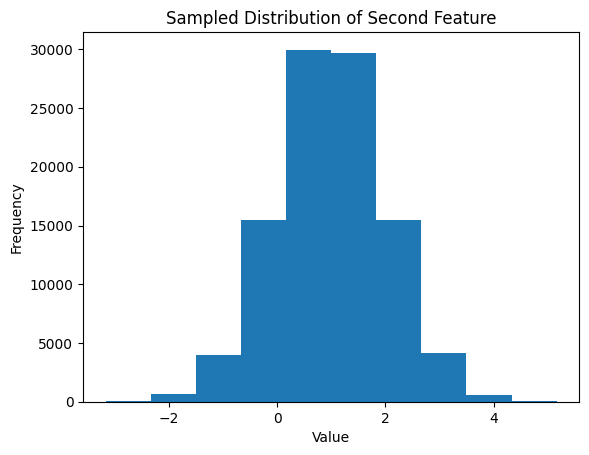

T-test results for the second feature of generated and sampled data:
TtestResult(statistic=0.6307211745131542, pvalue=0.5282235722161771, df=199997.87765707463)


In [167]:
plt.hist(generated_data[:, 1])
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Generated Distribution of Second Feature")
plt.show()

plt.hist(sampled_data[:, 1])
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Sampled Distribution of Second Feature")
plt.show()

print("T-test results for the second feature of generated and sampled data:")
print(ttest_ind(generated_data[:, 1], sampled_data[:, 1], equal_var=False))

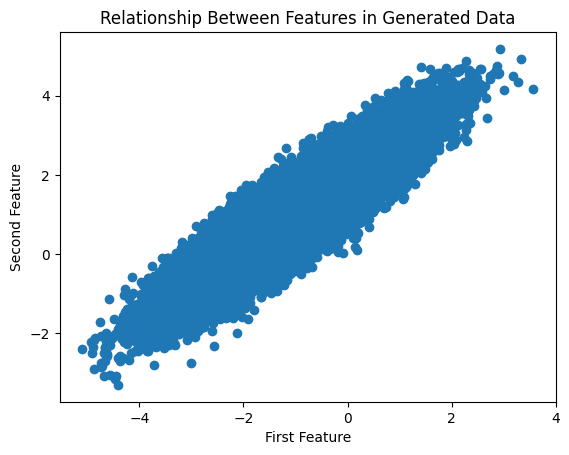

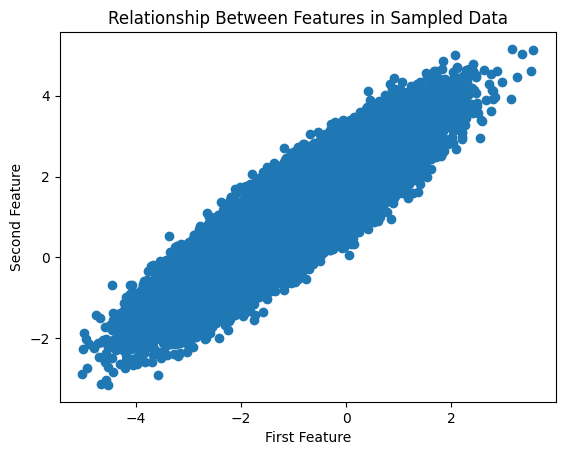

In [168]:
plt.scatter(generated_data[:, 0], generated_data[:, 1])
plt.xlabel("First Feature")
plt.ylabel("Second Feature")
plt.title("Relationship Between Features in Generated Data")
plt.show()

plt.scatter(sampled_data[:, 0], sampled_data[:, 1])
plt.xlabel("First Feature")
plt.ylabel("Second Feature")
plt.title("Relationship Between Features in Sampled Data")
plt.show()

In [169]:
print("Correlation Matrix of generated data:")
print(torch.corrcoef(generated_data.T))

Correlation Matrix of generated data:
tensor([[1.0000, 0.8992],
        [0.8992, 1.0000]])


In [170]:
print("Correlation Matrix of sampled data:")
print(torch.corrcoef(sampled_data.T))

Correlation Matrix of sampled data:
tensor([[1.0000, 0.8899],
        [0.8899, 1.0000]])


In [171]:
print("T-Test for two standard normal distributions:")
print(ttest_ind(torch.randn(N_SAMPLES_GENERATED), torch.randn(N_SAMPLES_GENERATED), equal_var=False))

T-Test for two standard normal distributions:
TtestResult(statistic=-0.296082669793906, pvalue=0.767167255870477, df=199997.46591173692)
